In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion

In [ ]:
matrix = np.array([[2, 5, 1, 7],
                   [2, 4, 5, 1],
                   [0, 1, 2, 4]])

matrix = np.array([
    [150, 152, 148, 149],
    [147, 152, 151, 150],
    [152, 148, 149, 151],
    [151, 149, 150, 148]
])

matrix = np.array([[180, 245, 250, 220],
                   [210, 225, 215, 215],
                   [218, 230, 220, 212],
                   [222, 215, 218, 210]])

In [ ]:
EXPRESSION_STATEMENT = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'X', '+', '-', '*', '/', '.']

def apply_expression(expression: str, x: int):
    expression = ''.join(char for char in expression.upper() if char in EXPRESSION_STATEMENT)
    expression = expression.split('X')
    expression[1:] = [expression[1][0], expression[1][1:]]

    a = float(expression[0])
    b = float(expression[2])
    operator = expression[1]

    if len(expression) != 3 or a > 255 or b > 255:
        raise

    if operator == '+':
        return int(np.clip(np.clip(a*x, 0, 255) + b, 0, 255))
    elif operator == '-':
        return int(np.clip(np.clip(a*x, 0, 255) - b, 0, 255))
    elif operator == '*':
        return int(np.clip(np.clip(a*x, 0, 255) * b, 0, 255))
    elif operator == '/':
        return int(np.clip(np.clip(a*x, 0, 255) / b, 0, 255))
    else:
        raise

In [8]:
def gammaCorrection(matrix: np.ndarray, b: int = 8, y: float = 1, c: int = 1) -> np.ndarray:
    def gamma(x: int, b: int = 8, y: float = 1, c: int = 1) -> int:
        return round(c * ((2**b - 1) * ((x / (2**b - 1)) ** y)))

    LUT = [gamma(x, b, y, c) for x in range(2 ** b)]

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            matrix[i][j] = LUT[matrix[i][j]]

    return matrix

In [10]:
def histogramStretching(matrix, b):
    def stretch(Pixel: int, Min: int, Max: int):
        return np.clip(np.round((2**b+.0 * (Pixel - Min) / (Max - Min))), 0, 2**b)

    Min, Max = np.min(matrix), np.max(matrix)
    LUT = [stretch(p, Min, Max) for p in range(256)]

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            matrix[i][j] = LUT[matrix[i][j]]

    return matrix

In [11]:
def histogramEqualizing(matrix, b):
    Histogram = matrix.histogram()
    SUM = np.sum(Histogram)
    PDF = [i / SUM for i in Histogram]
    CDF = np.cumsum(PDF)
    LUT = [np.clip(np.round(i * 2**b), 0, 2**b) for i in CDF]
 
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            matrix[i][j] = LUT[matrix[i][j]]

    return matrix

In [18]:
def _get_rank(Matrix, Rank):
    return np.sort(Matrix.flatten())[Rank - 1]

def _get_mode(Matrix):
    values, counts = np.unique(Matrix.ravel(), return_counts=True)
    modes = values[counts == np.max(counts)]
    return np.mean(modes)

_KERNELS = {
    'MEAN'   : np.mean,
    'AVERAGE': np.mean,
    'MEDIAN' : np.median,
    'RANGE'  : np.ptp,
    'SUM'    : np.sum,
    'MIN'    : np.min,
    'MAX'    : np.max,
    'MODE'   : _get_mode
}

def _get_kernel_mode(kernel_string):
    kernel_string = kernel_string.upper()
    if kernel_string.startswith('RANK'):
        return kernel_string
    elif kernel_string.startswith('OUTLIER'):
        return kernel_string
    else:
        return _KERNELS[kernel_string]

def neighborhood_operations(matrix, kernel_string: str, kernel_size: tuple[int, int]):
    output_matrix = np.zeros_like(matrix, dtype=int)
    padded_matrix = np.pad(matrix, (int(np.ceil(kernel_size[0] / 2)), int(np.ceil(kernel_size[1] / 2))), mode='constant', constant_values=0)

    kernel_mode = _get_kernel_mode(kernel_string=kernel_string)

    if isinstance(kernel_mode, str):
        if kernel_mode.startswith('RANK'):
            Rank = int(kernel_mode.split()[-1]) # e.g. 'Rank 3'
            for i in range(matrix.shape[0]):
                for j in range(matrix.shape[1]):
                    neighborhood_matrix = padded_matrix[i:i+kernel_size[0], j:j+kernel_size[1]]
                    output_matrix[i, j] = np.clip(np.round(_get_rank(neighborhood_matrix, Rank)), 0, 255)

        elif kernel_mode.startswith('OUTLIER'):
            Threshold = int(kernel_mode.split()[-1]) # e.g. 'Outlier 10'
            for i in range(matrix.shape[0]):
                for j in range(matrix.shape[1]):
                    neighborhood_matrix = padded_matrix[i:i+kernel_size[0], j:j+kernel_size[1]]
                    pixel = matrix[i, j]
                    neighbors_mean = np.mean(neighborhood_matrix[neighborhood_matrix != pixel])
                    output_matrix[i, j] = np.round(neighbors_mean) if abs(pixel - neighbors_mean) > Threshold else pixel

    else:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                neighborhood_matrix = padded_matrix[i:i+kernel_size[0], j:j+kernel_size[1]]
                output_matrix[i, j] = np.clip(np.round(kernel_mode(neighborhood_matrix)), 0, 255)

    return output_matrix

In [ ]:
 #! These functions only work on square metrices
 
def apply_LPF(matrix, weights: np.ndarray):
    kernel_size = weights.shape[0]
    output_matrix = np.zeros_like(matrix, dtype=int)
    padded_matrix = np.pad(matrix, kernel_size // 2, mode='constant', constant_values=0)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            neighborhood_matrix = padded_matrix[i:i+kernel_size, j:j+kernel_size]
            output_matrix[i, j] = np.clip(np.round((neighborhood_matrix * weights) / np.sum(weights)), 0, 255)

    return output_matrix


def apply_HPF(matrix, weights: np.ndarray):
    kernel_size = weights.shape[0]
    output_matrix = np.zeros_like(matrix, dtype=int)
    padded_matrix = np.pad(matrix, kernel_size // 2, mode='constant', constant_values=0)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            neighborhood_matrix = padded_matrix[i:i+kernel_size, j:j+kernel_size]
            output_matrix[i, j] = np.clip(np.round(np.sum(neighborhood_matrix * weights)), 0, 255)

    return output_matrix

In [ ]:
DEFAULT_WEIGHTS = np.array([[1, 2, 1],
                            [2, 4, 2],
                            [1, 2, 1]])

def weighted_averaging(matrix):
    return apply_LPF(matrix, DEFAULT_WEIGHTS)

LAPLACIAN = np.array([[ 1, -2,  1],
                      [-2,  4, -2],
                      [ 1, -2,  1]])

def laplacian(matrix):
    return apply_HPF(matrix, LAPLACIAN)

In [ ]:
def global_threshold(matrix, threshold, low=0, high=255):
    matrix[matrix <= threshold] = low
    matrix[matrix >  threshold] = high
    return matrix


def automatic_threshold(matrix, delta=0.75, max_iterations=10):
    matrix = matrix.flatten()
    theta = np.mean(matrix)

    i = 0
    while i <= max_iterations:
        print(f'Theta {i}: {theta:.3f}{' (Mean)' if i == 0 else ''}')

        a = matrix[matrix <= theta]
        b = matrix[matrix >  theta]

        pre_theta = theta
        theta = 0.5 * (np.mean(a) + np.mean(b))

        if abs(theta - pre_theta) <= delta:
            break
        else:
            i += 1
            continue

    return theta

In [159]:
def _dilation(A, B, ORG):
        return binary_dilation(A-1, structure=B, origin=ORG).astype('uint8')

def _erosion(A, B, ORG):
        return binary_erosion(A-1, structure=B, origin=ORG).astype('uint8')

def morphology(matrix, operation, struct_element=np.ones(shape=(3, 3), dtype=int), ORG=-1):
    if operation == 'DILATION':
        matrix = _dilation(A=matrix, B=struct_element, ORG=ORG)
    elif operation == 'EROSION':
        matrix = _erosion(A=matrix, B=struct_element, ORG=ORG)
    elif operation == 'OPENING':
        matrix = _dilation(A=_erosion(A=matrix, B=struct_element, ORG=ORG), B=struct_element, ORG=ORG)
    elif operation == 'CLOSING':
        matrix = _erosion(A=_dilation(A=matrix, B=struct_element, ORG=ORG), B=struct_element, ORG=ORG)
    elif operation == 'IN_BOUNDRY':
        matrix = abs(matrix - _erosion(A=matrix, B=struct_element, ORG=ORG))
    elif operation == 'EX_BOUNDRY':
        matrix = abs(_dilation(A=matrix, B=struct_element, ORG=ORG) - matrix)
    elif operation == 'GRADIENT':
        matrix = abs(_dilation(A=matrix, B=struct_element, ORG=ORG) - _erosion(A=matrix, B=struct_element, ORG=ORG))

    return matrix-1

def hit_or_miss(matrix, b1, b2):
    return _erosion(A=matrix, B=b1) & _erosion(A=matrix-1, B=b2)

In [153]:
def plot_morphology(matrix):
    plt.imshow(matrix, cmap='gray', extent=(0, matrix.shape[1], 0, matrix.shape[0]))
    plt.grid(True, which='both', color='0.5')
    plt.show()

def solve_morphology(matrix, *indices: tuple[tuple[int, int], ...]):
    for index in indices:
        print(f'White' if matrix[index[0]][index[1]] else 'Black')

Black
Black


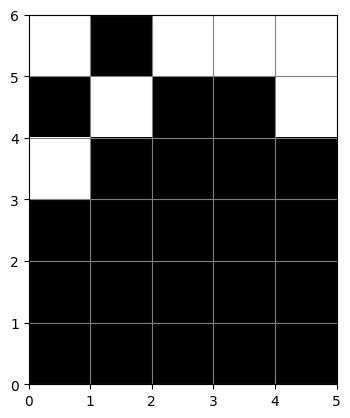

White
White


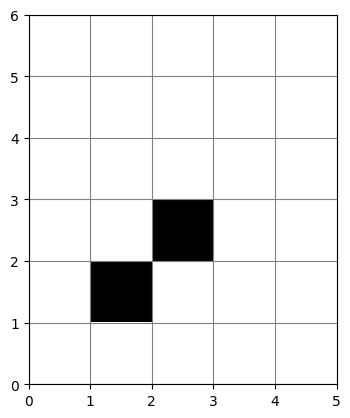

Black
Black


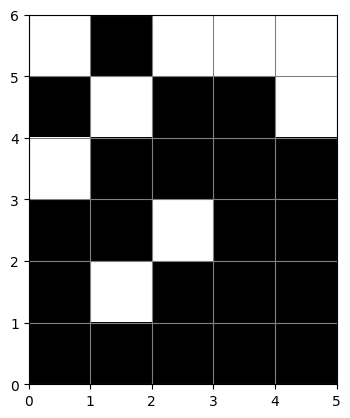

In [160]:
matrix = np.array([[0, 1, 1, 1, 1],
                   [1, 1, 1, 1, 1],
                   [1, 1, 0, 0, 1],
                   [1, 0, 0, 0, 1],
                   [0, 0, 0, 0, 1],
                   [0, 0, 1, 0, 1]])

element = np.array([[0, 1, 0],
                    [1, 0, 1],
                    [0, 1, 0]])

orgin = 0

x = morphology(matrix=matrix, operation='DILATION', struct_element=element, ORG=orgin)
solve_morphology(x, (2, 2), (4, 2))
plot_morphology(x)

y = morphology(matrix=matrix, operation='EROSION', struct_element=element, ORG=orgin)
solve_morphology(y, (2, 2), (4, 2))
plot_morphology(y)

z = morphology(matrix=matrix, operation='GRADIENT', struct_element=element, ORG=orgin)
solve_morphology(z, (2, 2), (4, 2))
plot_morphology(z)